# Week4 - Homework 2

- Execute the below code, then answer the numbered questions.
- You can create additinal code and markdown blocks

In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/regression/car-reg-data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9055 entries, 0 to 9054
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   make           8164 non-null   object 
 1   transmission   8106 non-null   object 
 2   state          8152 non-null   object 
 3   condition      8173 non-null   float64
 4   odometer       8178 non-null   float64
 5   auction_value  8107 non-null   float64
 6   selling_price  9055 non-null   float64
dtypes: float64(4), object(3)
memory usage: 495.3+ KB


## Question 1:
### Which features can we use?

In [2]:
# analysis code for Q1.1.1
# Target: selling_price
# Features are all the other columns in the datase
features = ['make', 'transmission', 'state', 'condition', 'odometer', 'auction_value']

print("Target:", 'selling_price')
print("Selected features:", features)

Target: selling_price
Selected features: ['make', 'transmission', 'state', 'condition', 'odometer', 'auction_value']


Your explanation?

we are predicting selling_price and using all other columbs as feature 

make,transmissin, state are catagorical

condition , ododmeter,auction_value are numerical

In [5]:
from sklearn.model_selection import train_test_split

# Defineing the predictor variables all columns except the target
features = ['make', 'transmission', 'state', 
            'condition', 'odometer', 'auction_value']
# Createing X as independent variables using the selected features
X = df[features]
# Defineing y as the target variable that we are predicting
y = df['selling_price']
# Spliting the dataset into training (80%) and testing (20%) sets
# random_state is to ensure we get the same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100
)
#  Printing dataset information to confirm the split worked correctly
print(f'Records in training data: {X_train.shape[0]:,}')
print(f'Records in test data: {X_test.shape[0]:,}')
print('\nFeatures:')
print(*X_train.columns, sep='\n')

Records in training data: 7,244
Records in test data: 1,811

Features:
make
transmission
state
condition
odometer
auction_value


## Question 2: 
Split the features into two lists, one for the numerical features and another for the categorical features.

In [6]:
# Defineing numerical features 
numerical_features = ['condition', 'odometer', 'auction_value']
# Define categorical features 
categorical_features = ['make', 'transmission', 'state']
# Printing numerical features to verify
print("Numerical Features:")
print(*numerical_features, sep='\n')
# Printing categorical features to verify
print("\nCategorical Features:")
print(*categorical_features, sep='\n')


Numerical Features:
condition
odometer
auction_value

Categorical Features:
make
transmission
state


Explanation 

the features are seperated on the bases of their data types the numeric featuer contains continious valus and will require scaling  catagorical fatures  contain text based lable and require encoding befor modeling 

## Question 3: 
 Using the numerical variables, create a pipeline that replaces the missing values with the median and then standardizes the values using a standard scaler.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# Defineing the numerical columns that need preprocessing
numerical_features = ['condition', 'odometer', 'auction_value']
# Createing a pipeline for numerical data
numerical_pipeline = Pipeline(steps=[
     # Replaceing missing values in numeric columns with the median
    ('imputer', SimpleImputer(strategy='median')),
     # Standardize values so they have mean=0 and standard deviation=1
    ('scaler', StandardScaler())
])

## Question 4: 
Using the categorical variables, create a pipeline that replaces the missing values with the most frequent and then use one-hot encoding to convert the data to numerical arrays.
- You should be dropping one category from each variable when using the one-hot encoder.  
- To ensure the pipeline doesn't break when it receives new/unexpected categories, you should ignore new categories.
- Use a fit transformer on the training dataset to validate all the columns are now numeric and to determine how many columns the transformed data contains.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import numpy as np
# Defineing categorical columns
categorical_features = ['make', 'transmission', 'state']
# Createing categorical preprocessing pipeline
categorical_pipeline = Pipeline(steps=[
    # Replaceing missing values with the most frequent category
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # sparse_output=False ensures output is a dense numeric array
    ('onehot', OneHotEncoder(drop='first',
                             handle_unknown='ignore',
                             sparse_output=False))
])
# Fiting and transform the training data
X_train_cat_transformed = categorical_pipeline.fit_transform(X_train[categorical_features])
# Confirming output is numeric
print("Is the transformed data numeric?:",
      np.issubdtype(X_train_cat_transformed.dtype, np.number))
# Showing number of columns created
print("Transformed training shape:", X_train_cat_transformed.shape)
print("Number of categorical columns after encoding:",
      X_train_cat_transformed.shape[1])

Is the transformed data numeric?: True
Transformed training shape: (7244, 41)
Number of categorical columns after encoding: 41


## Question 5: 

Combine the numerical and categorical pipelines into one data processing pipeline.
- Use a fit transformers and the training dataset to verify the data has no missing values and the correct number of columns.

In [15]:
from sklearn.compose import ColumnTransformer
import numpy as np
# Defineing feature groups 
numerical_features = ['condition', 'odometer', 'auction_value']
categorical_features = ['make', 'transmission', 'state']
# Combineing both pipelines into one preprocessing step
data_processing_pipeline = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),      
    ('cat', categorical_pipeline, categorical_features)   
])
# Fit + transforming only on training data this is to prevent data leakage
X_train_processed = data_processing_pipeline.fit_transform(X_train)
# Verify there are no missing values after preprocessing
missing_count = np.isnan(X_train_processed).sum()
print("Total missing values after preprocessing:", missing_count)
# Verifying the number of columns after transformation
print("Processed training shape (rows, columns):", X_train_processed.shape)
print("Number of columns after transformation:", X_train_processed.shape[1])

Total missing values after preprocessing: 0
Processed training shape (rows, columns): (7244, 44)
Number of columns after transformation: 44


## Question 6: 

Add a linear regression model to the pipeline.
- Report what the $R^2$ is using the `test` data.  

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
# Fully modeling pipeline = preprocessing + linear regression model
modeling_pipeline = Pipeline(steps=[
    ('preprocess', data_processing_pipeline),  
    ('lr', LinearRegression())                  
])
# Training (fit) the full pipeline on the training data
modeling_pipeline.fit(X_train, y_train)
# R2 score on the test set 
r2 = modeling_pipeline.score(X_test, y_test)
# Printing the result
print("Test R^2:", r2)

Test R^2: 0.883827442491126


## Question 7: 

Create a plot(s) of the residuals. Do you have any concerns about patterns in the residuals that the model is neglecting to pick-up?
- Include a sentence or two on what you observe.

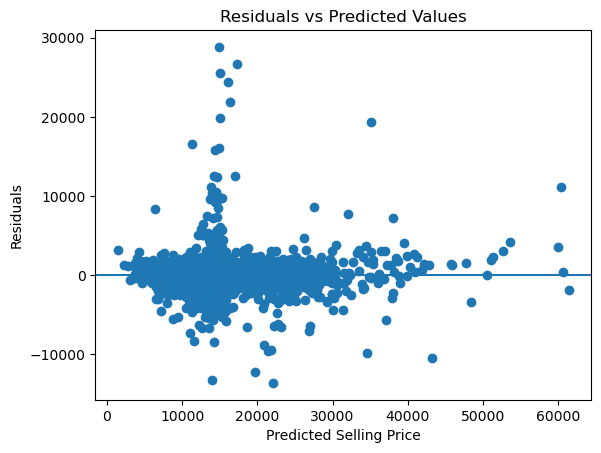

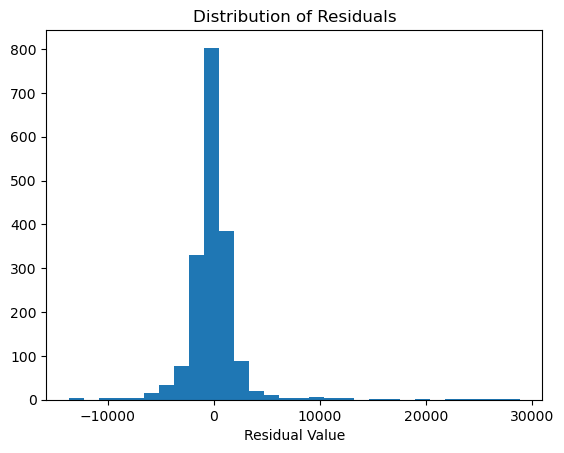

In [18]:
import matplotlib.pyplot as plt
import numpy as np
# Predicting values using the test data
y_pred = modeling_pipeline.predict(X_test)
# Calculateing residuals 
residuals = y_test - y_pred
#Createing Residuals vs Predicted plot
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()
# Createing Histogram of residuals
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual Value")
plt.title("Distribution of Residuals")
plt.show()

Observation 

The residuale is mostly centered near good which is good this suggests that the model is unbaised overall.Howerver there appears to be some variation in spread accross predicting values indicating possible heteroscedasticity.

the histogram looks roughlys centered but slightly skewed with some heavy tails

concerns -

some heteroscedasticity

some outliers




## Question 8: 

Modify the pipeline to use a ridge regression model with an alpha value of 100. How does this change the $R^2$?

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
# Ridge regression pipeline same preprocessing but different model
ridge_pipeline = Pipeline(steps=[
    ('preprocess', data_processing_pipeline),
    ('ridge', Ridge(alpha=100))
])
# Fiting on training data
ridge_pipeline.fit(X_train, y_train)
# R2 on test data
ridge_r2 = ridge_pipeline.score(X_test, y_test)
print("Ridge Test R^2 (alpha=100):", ridge_r2)

Ridge Test R^2 (alpha=100): 0.8825302488246178


the test R2 value of 0.8825 is achieved through ridge regression with an alpha value of 100 the two models show almost identical performance because regularization did not affect their results the ridge regression method reduces overfitting by imposing penalties on large coefficients but the model still maintains its original explanatory capacity